In [118]:
import cmaboss, pandas, maboss, json, collections
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### MaBoSS

In [126]:
sim = maboss.load("tuto/maboss/Fork-uneven.bnd", "tuto/maboss/Fork.cfg")

In [127]:
res = sim.run()

Text(0, 0.5, 'probabilities')

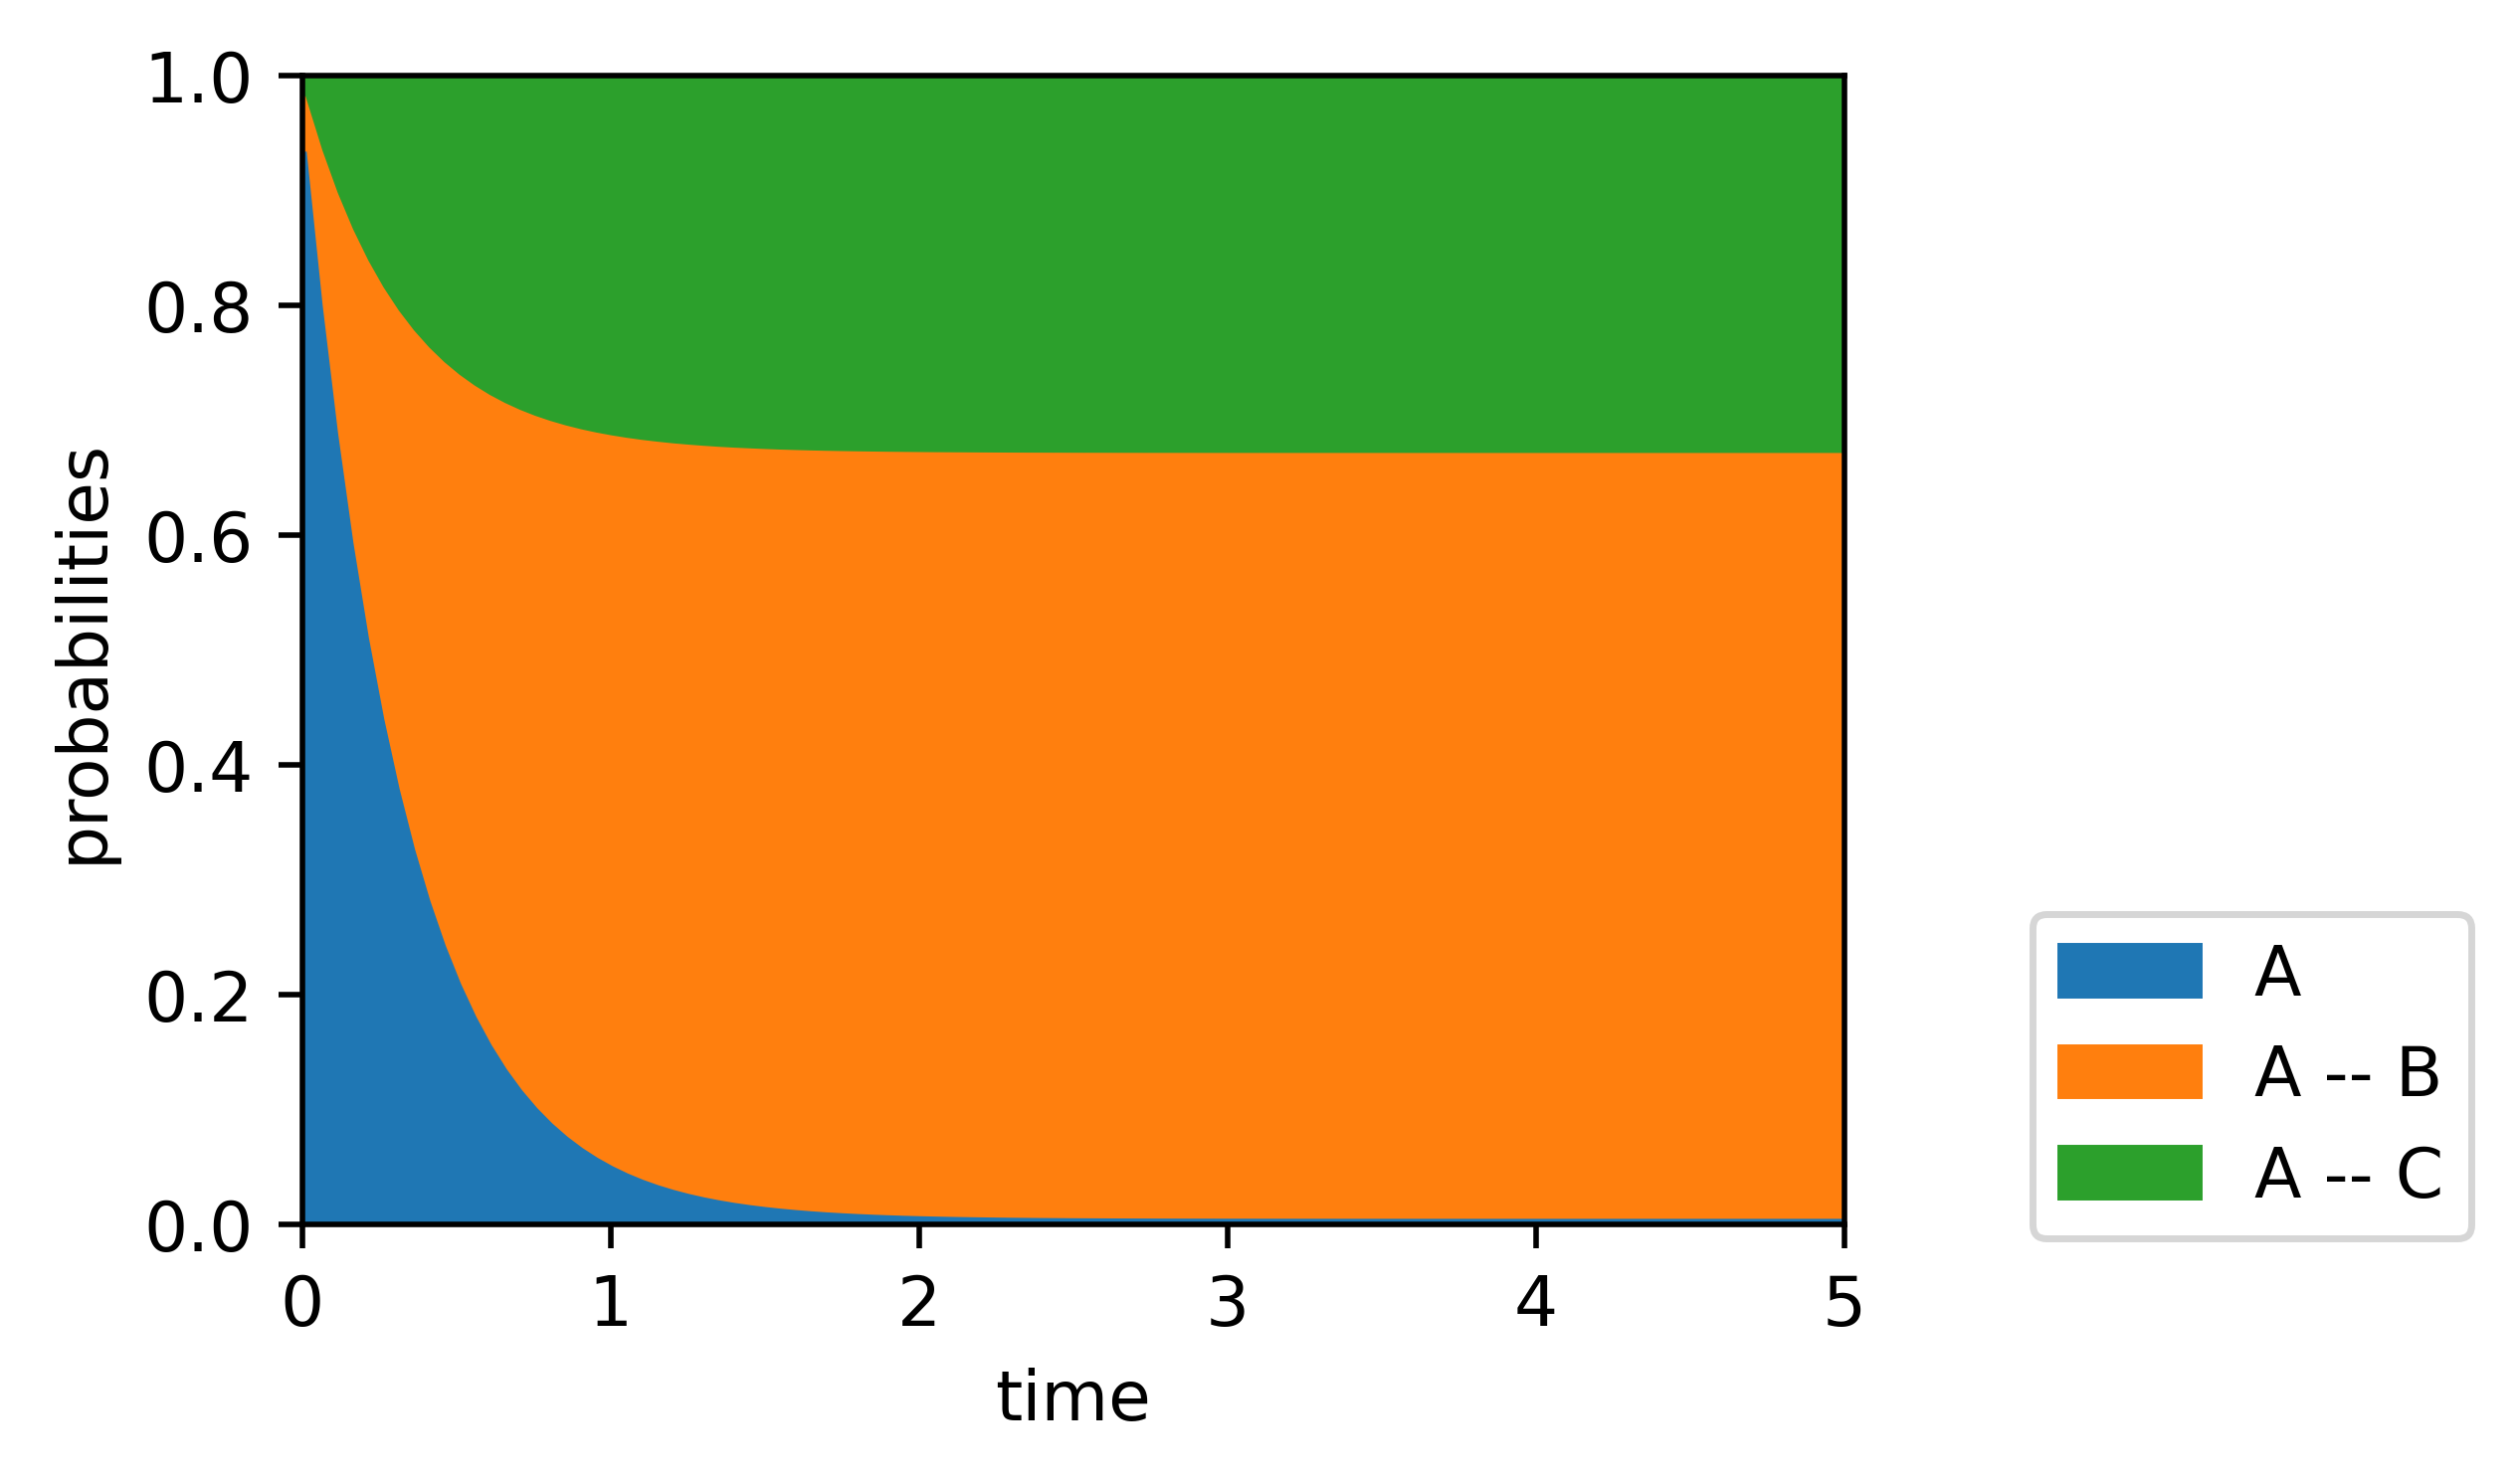

In [128]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
res.get_states_probtraj().plot.area(ax=ax)
plt.legend(bbox_to_anchor=(1.1, 0.3), loc='upper left')
plt.xlim(0,5)
plt.ylim(0,1)
plt.xlabel("time")
plt.ylabel("probabilities")

### UPMaBoSS

In [133]:
base_sim = maboss.load("tuto/upmaboss/Fork-uneven.bnd", "tuto/upmaboss/Fork-uneven.cfg")
up_sim = maboss.UpdatePopulation(base_sim, "tuto/upmaboss/Fork.upp")

In [134]:
up_res = up_sim.run()

In [135]:
table = up_res.get_stepwise_probability_distribution()
table.index = np.linspace(0,5,51)
states = table.drop('PopRatio', axis=1)
popratio = table['PopRatio']
states

,A,A -- B,A -- B -- Division,A -- C,A -- C -- Division,A -- Division
0.0,0.683900,0.158084,0.007288,0.079028,0.003587,0.068114
0.1,0.519803,0.280222,0.005549,0.139824,0.002762,0.051839
0.2,0.402186,0.367796,0.004272,0.183526,0.002156,0.040065
0.3,0.315192,0.432539,0.003343,0.215797,0.001682,0.031447
0.4,0.249445,0.481477,0.002663,0.240261,0.001316,0.024839
0.5,0.198814,0.519238,0.002137,0.258943,0.001060,0.019807
0.6,0.159357,0.548573,0.001707,0.273593,0.000856,0.015915
0.7,0.128391,0.571703,0.001352,0.285070,0.000642,0.012843
0.8,0.103854,0.590094,0.001082,0.294089,0.000519,0.010361
0.9,0.084178,0.604761,0.000844,0.301350,0.000446,0.008420


In [136]:
colors = {
    'A': 'C0', 
    'A -- Division': 'C3',
    'A -- B': 'C1', 
    'A -- B -- Division': 'C4', 
    'A -- C': 'C2', 
    'A -- C -- Division': 'C5'
}
colors

{'A': 'C0',
 'A -- Division': 'C3',
 'A -- B': 'C1',
 'A -- B -- Division': 'C4',
 'A -- C': 'C2',
 'A -- C -- Division': 'C5'}

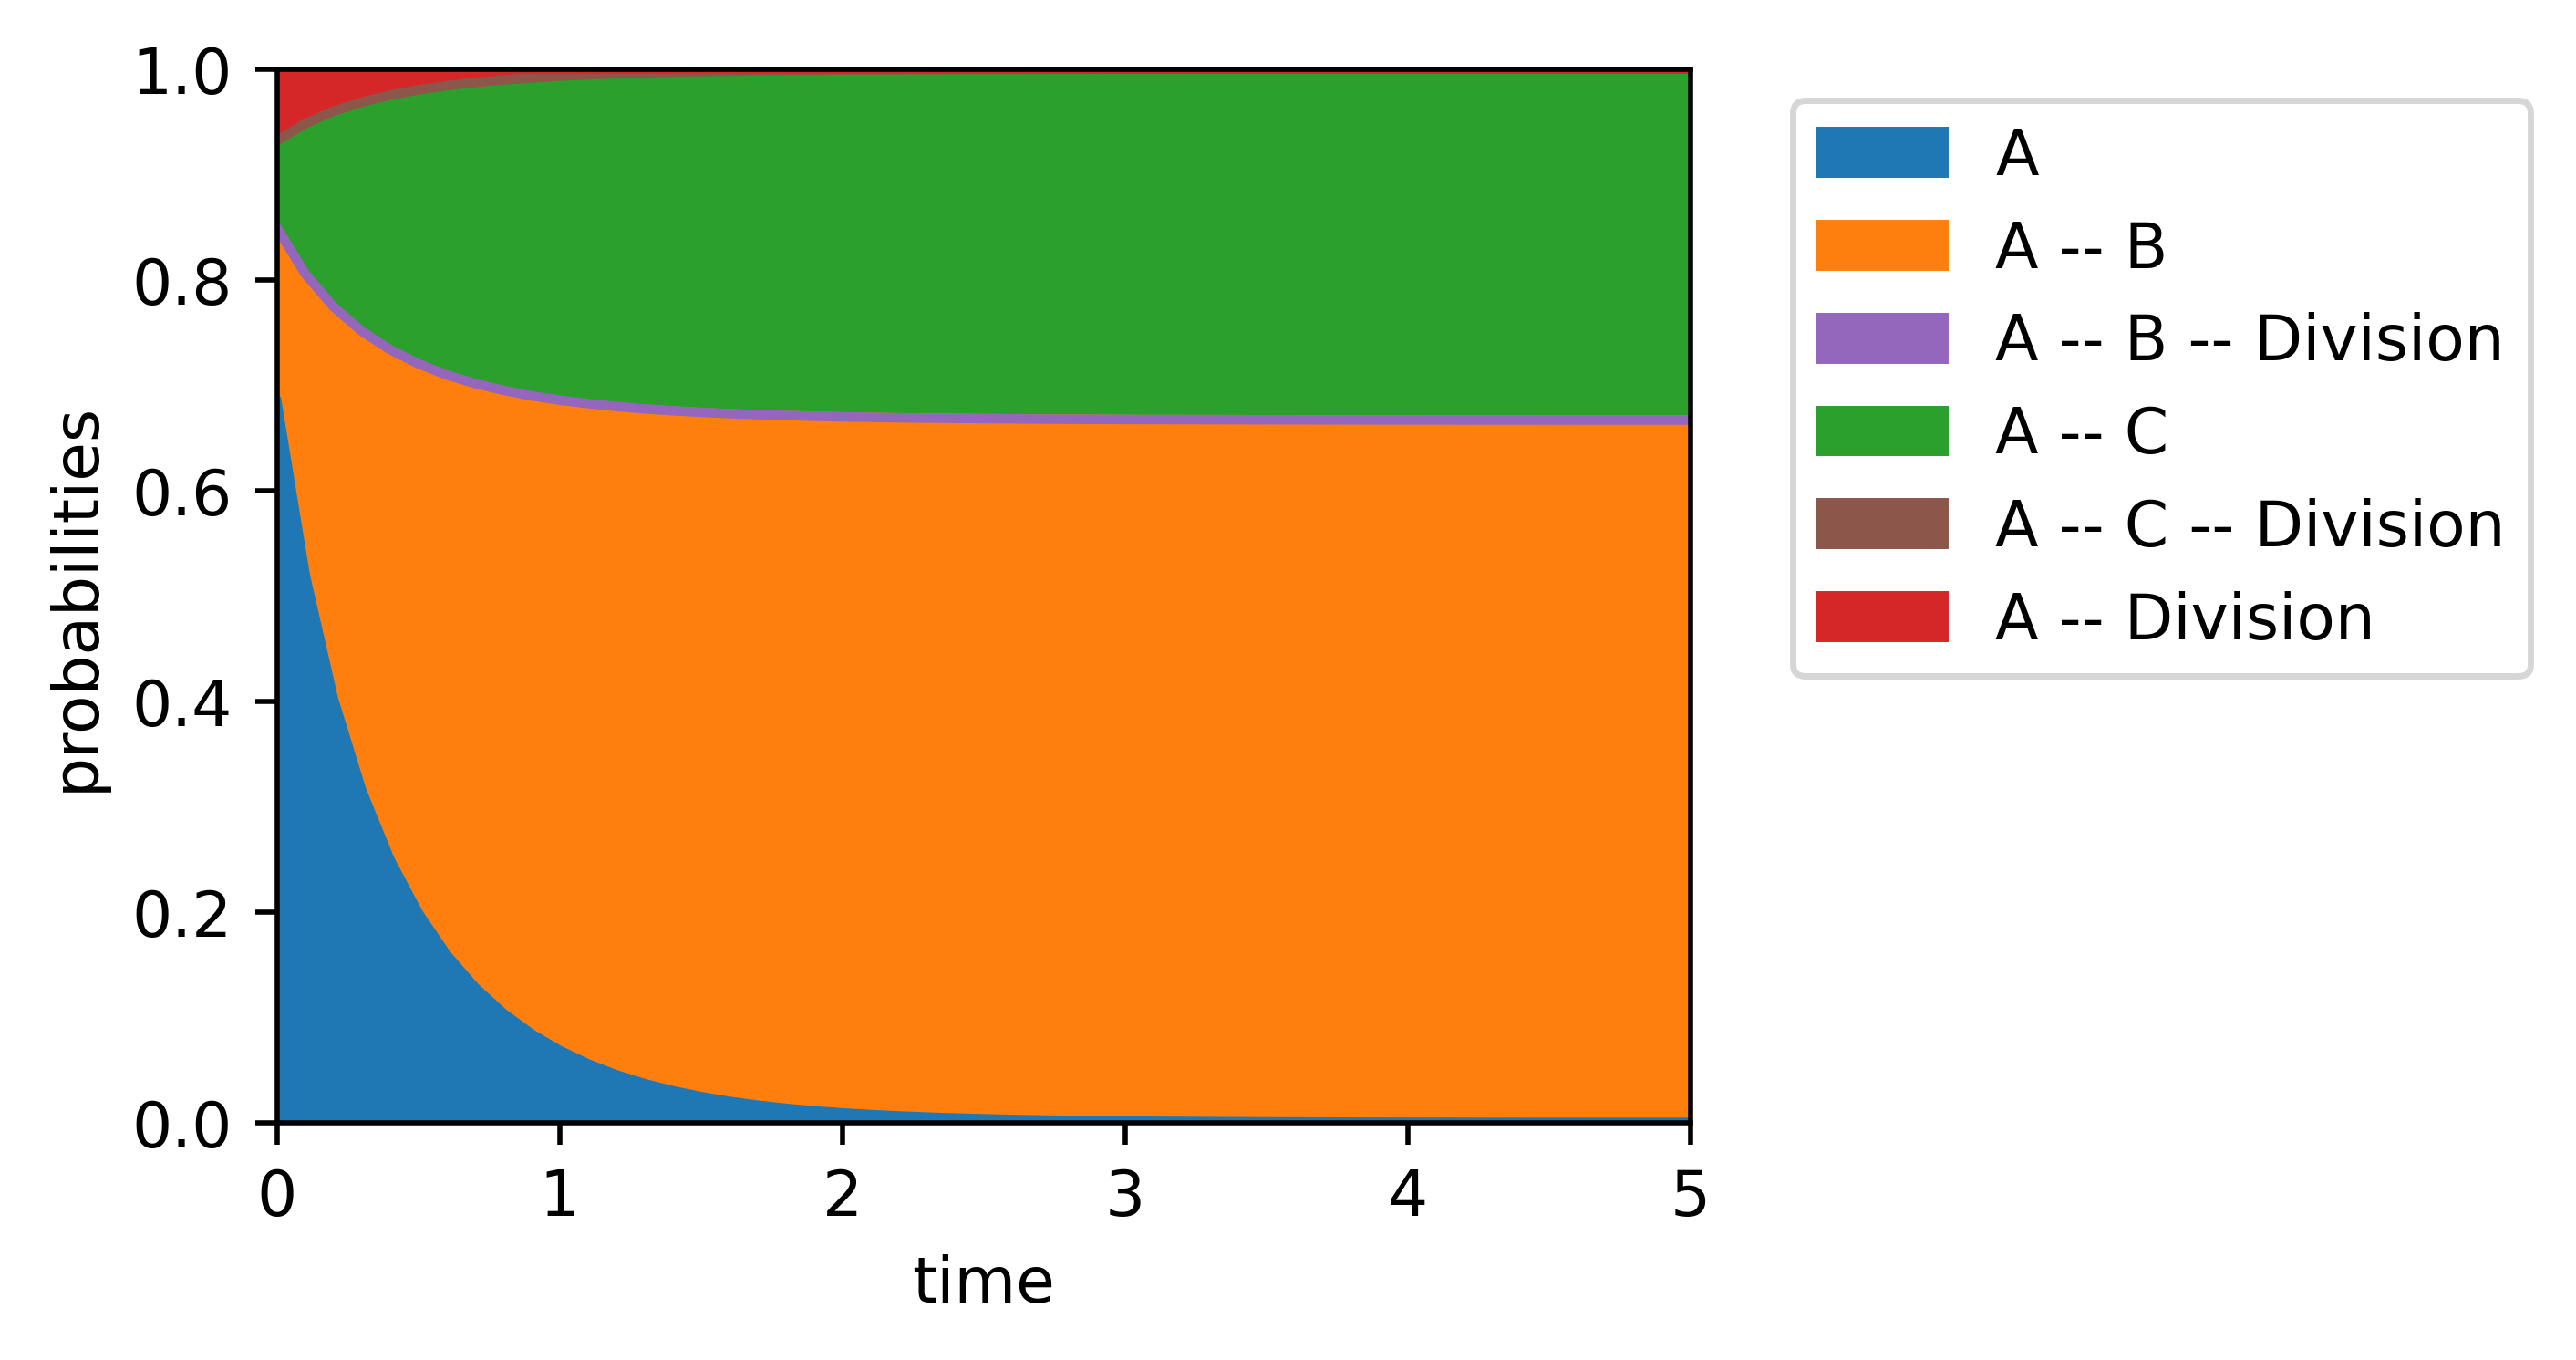

In [137]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
states.plot.area(ax=ax, color=colors)
plt.xlim(0,5)
plt.ylim(0,1)
plt.xlabel("time")
plt.ylabel("probabilities")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [138]:
def cleanup_states(table):
    for col in table.columns:
        nodes = col.split(" -- ")
        if 'Division' in nodes:
            new_nodes = nodes
            new_nodes.remove('Division')
            new_state = " -- ".join(new_nodes)
            table[new_state] = table[new_state] + table[col]
            table = table.drop(col, axis=1)
    return table

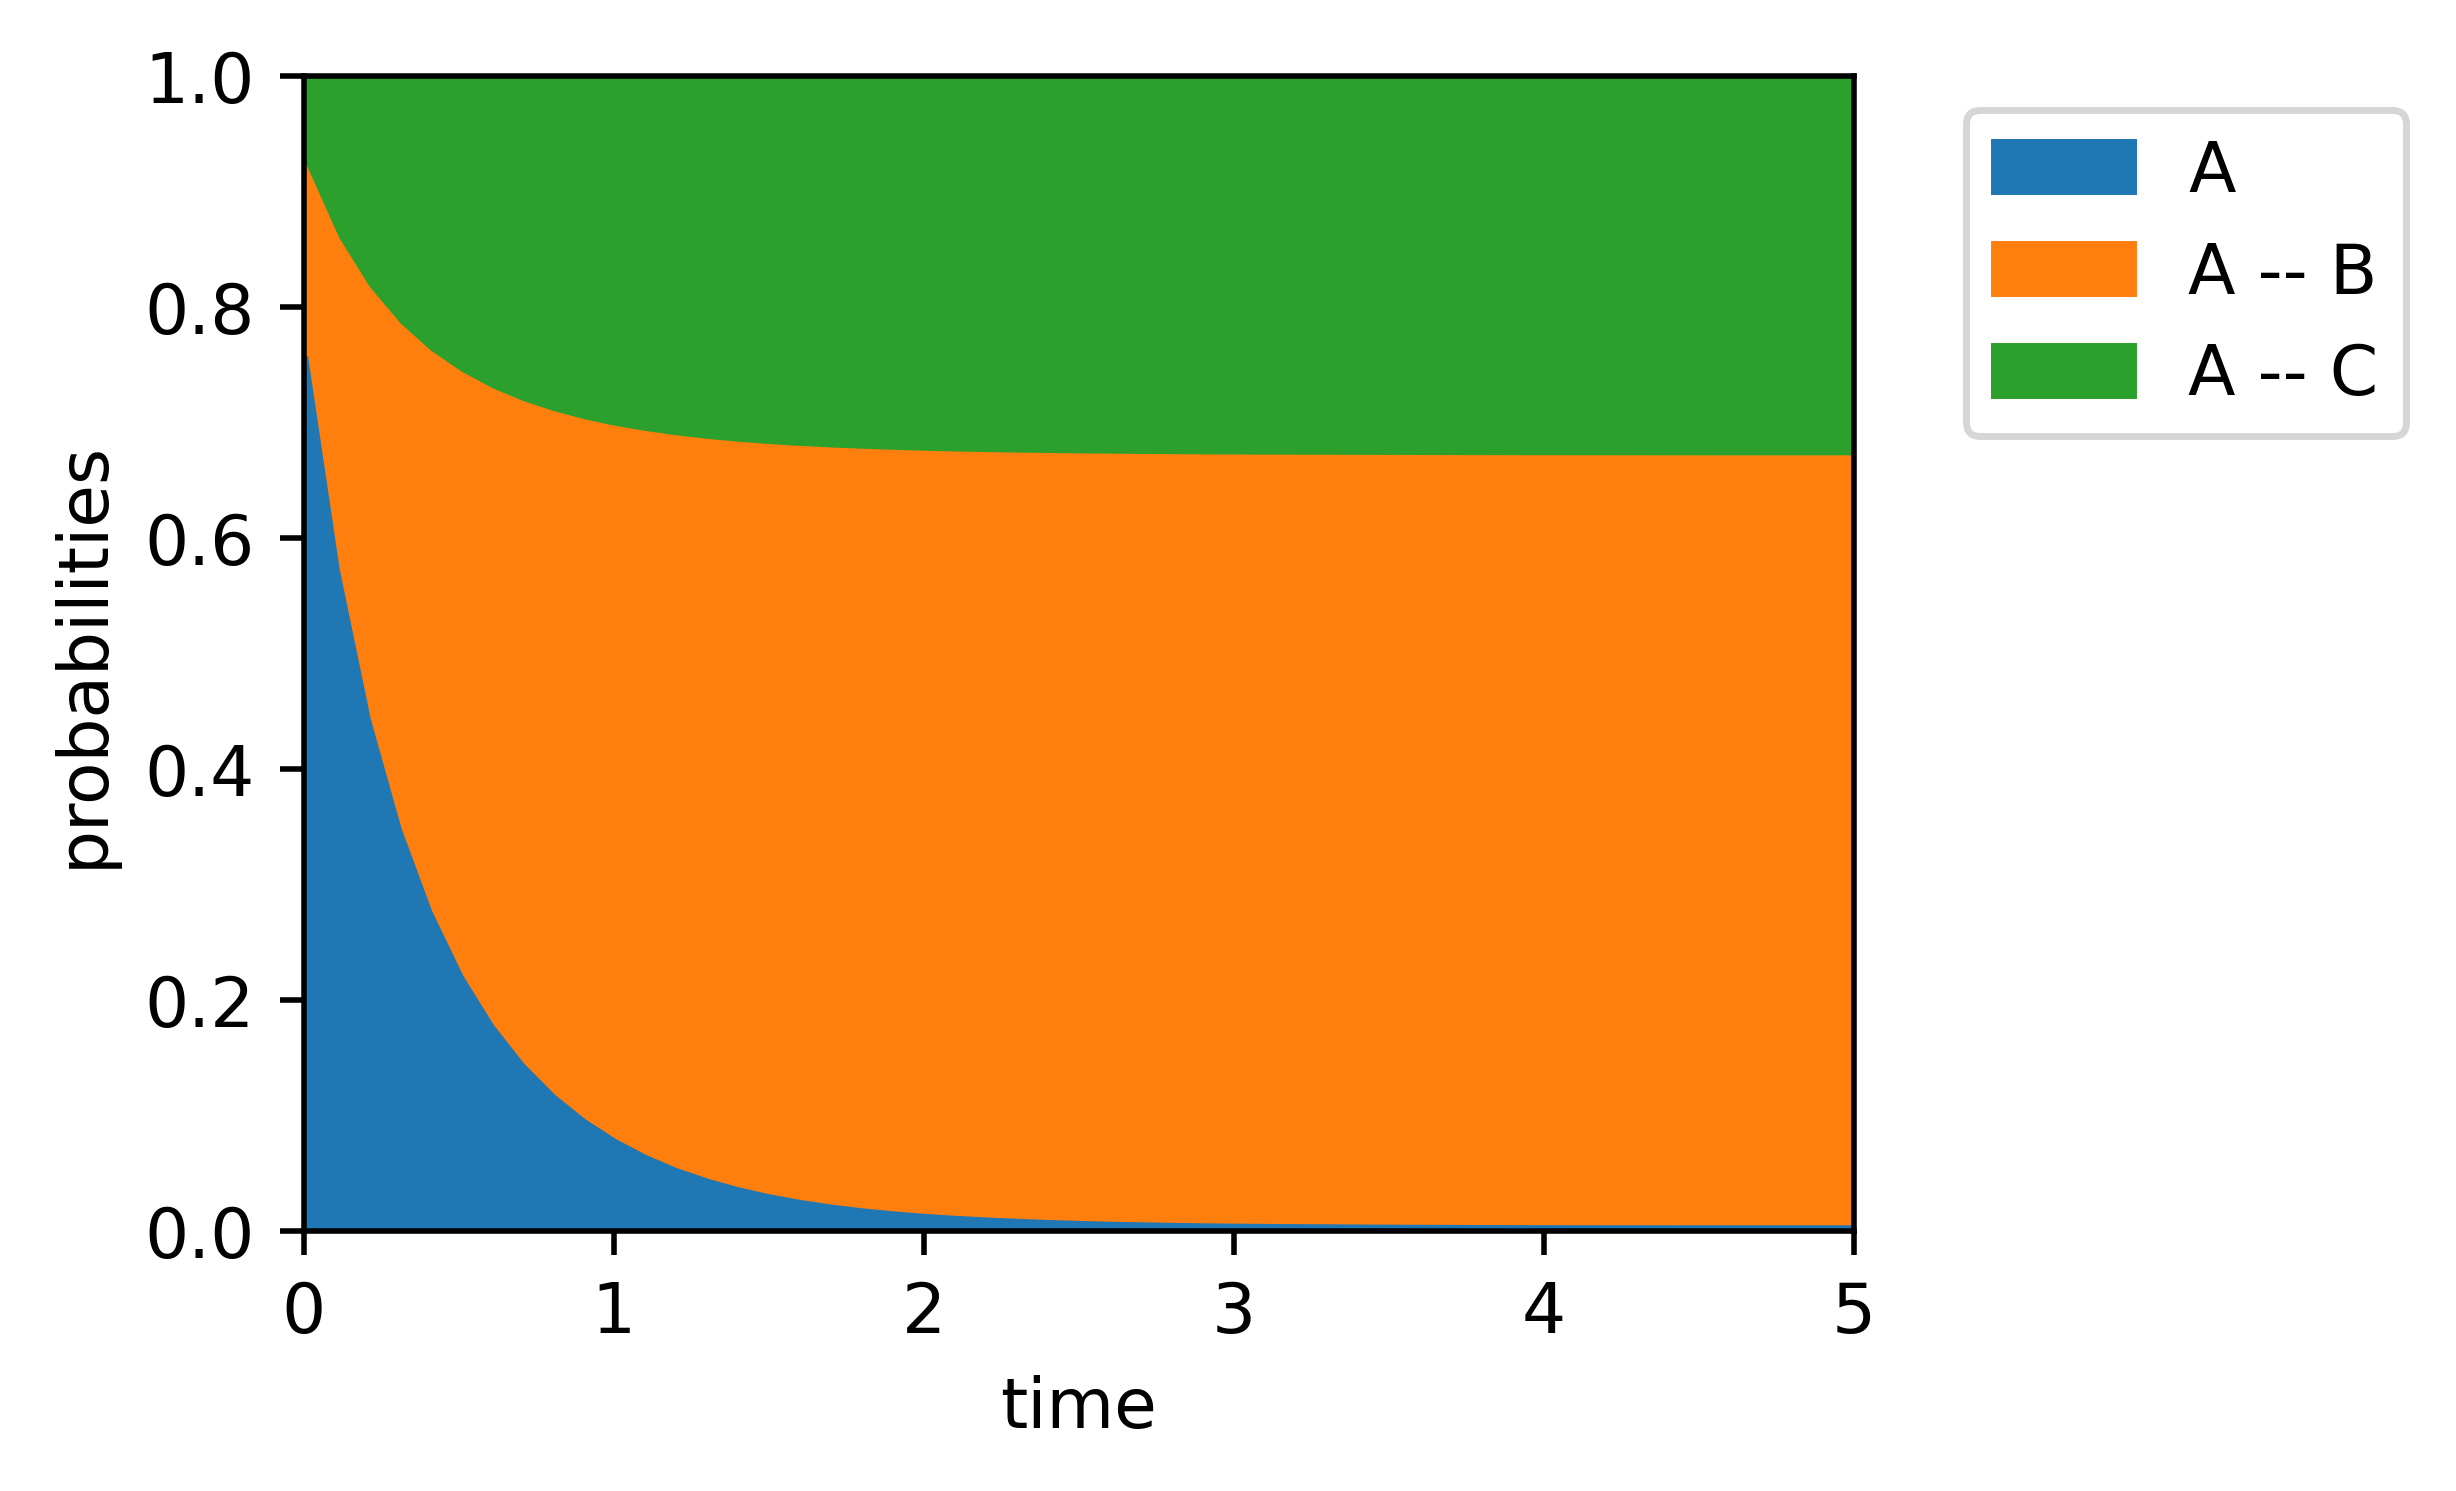

In [139]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
clean_states = cleanup_states(states)
clean_states.plot.area(ax=ax)
plt.xlim(0,5)
plt.ylim(0,1)
plt.xlabel("time")
plt.ylabel("probabilities")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Text(0, 0.5, 'population size')

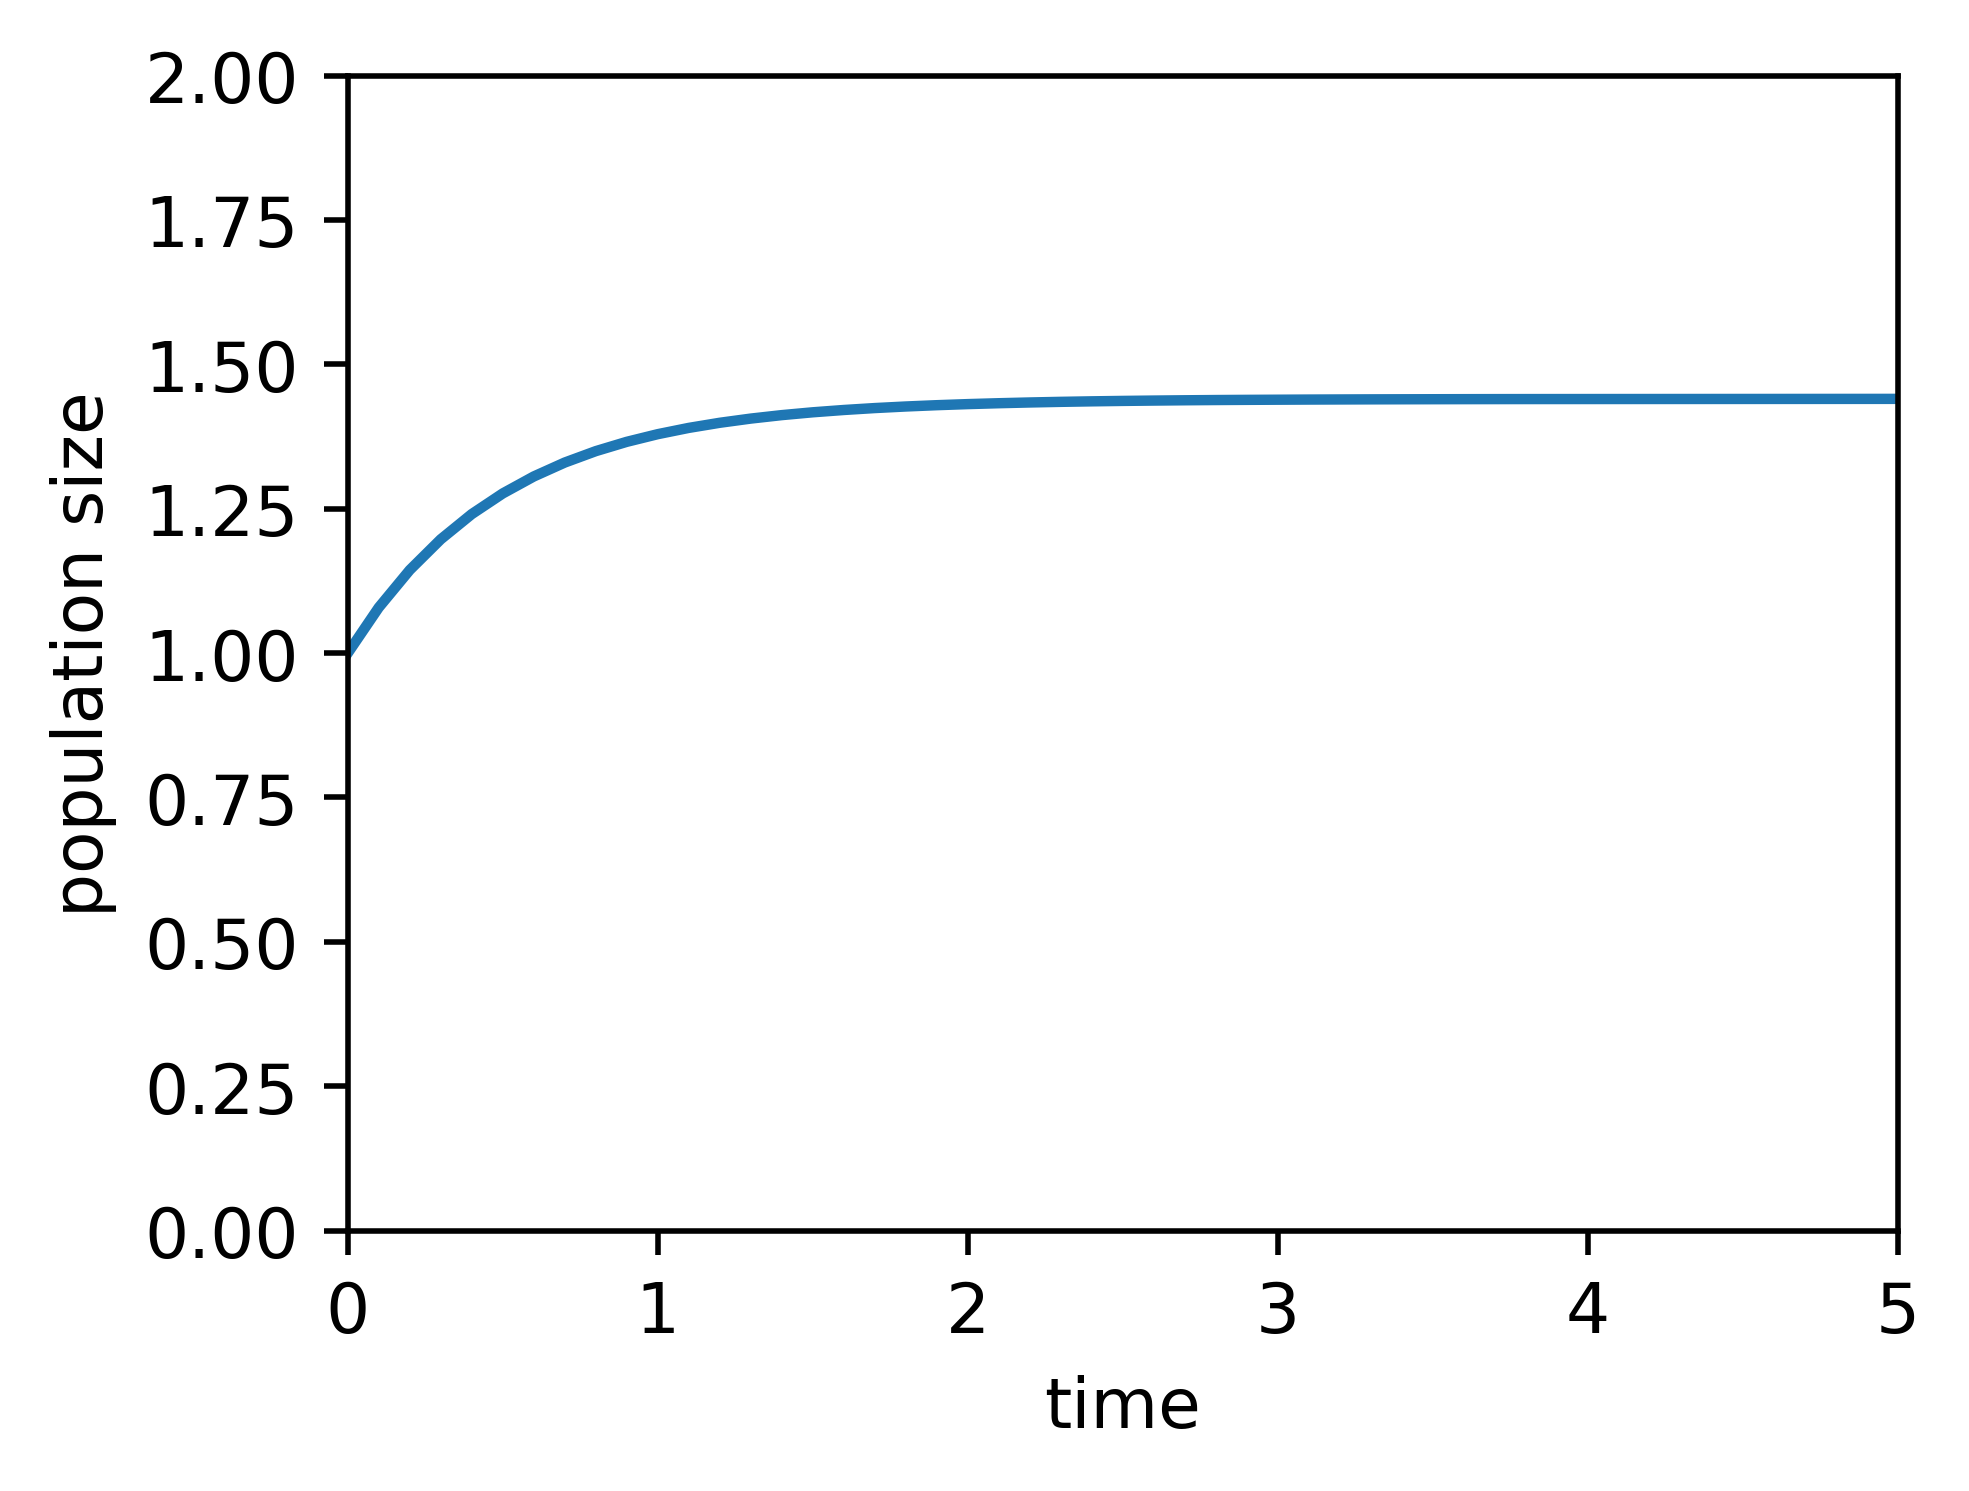

In [140]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
popratio.plot(ax=ax)
plt.xlim(0,5)
plt.ylim(0,2)
plt.xlabel("time")
plt.ylabel("population size")

Text(0, 0.5, 'population sizes')

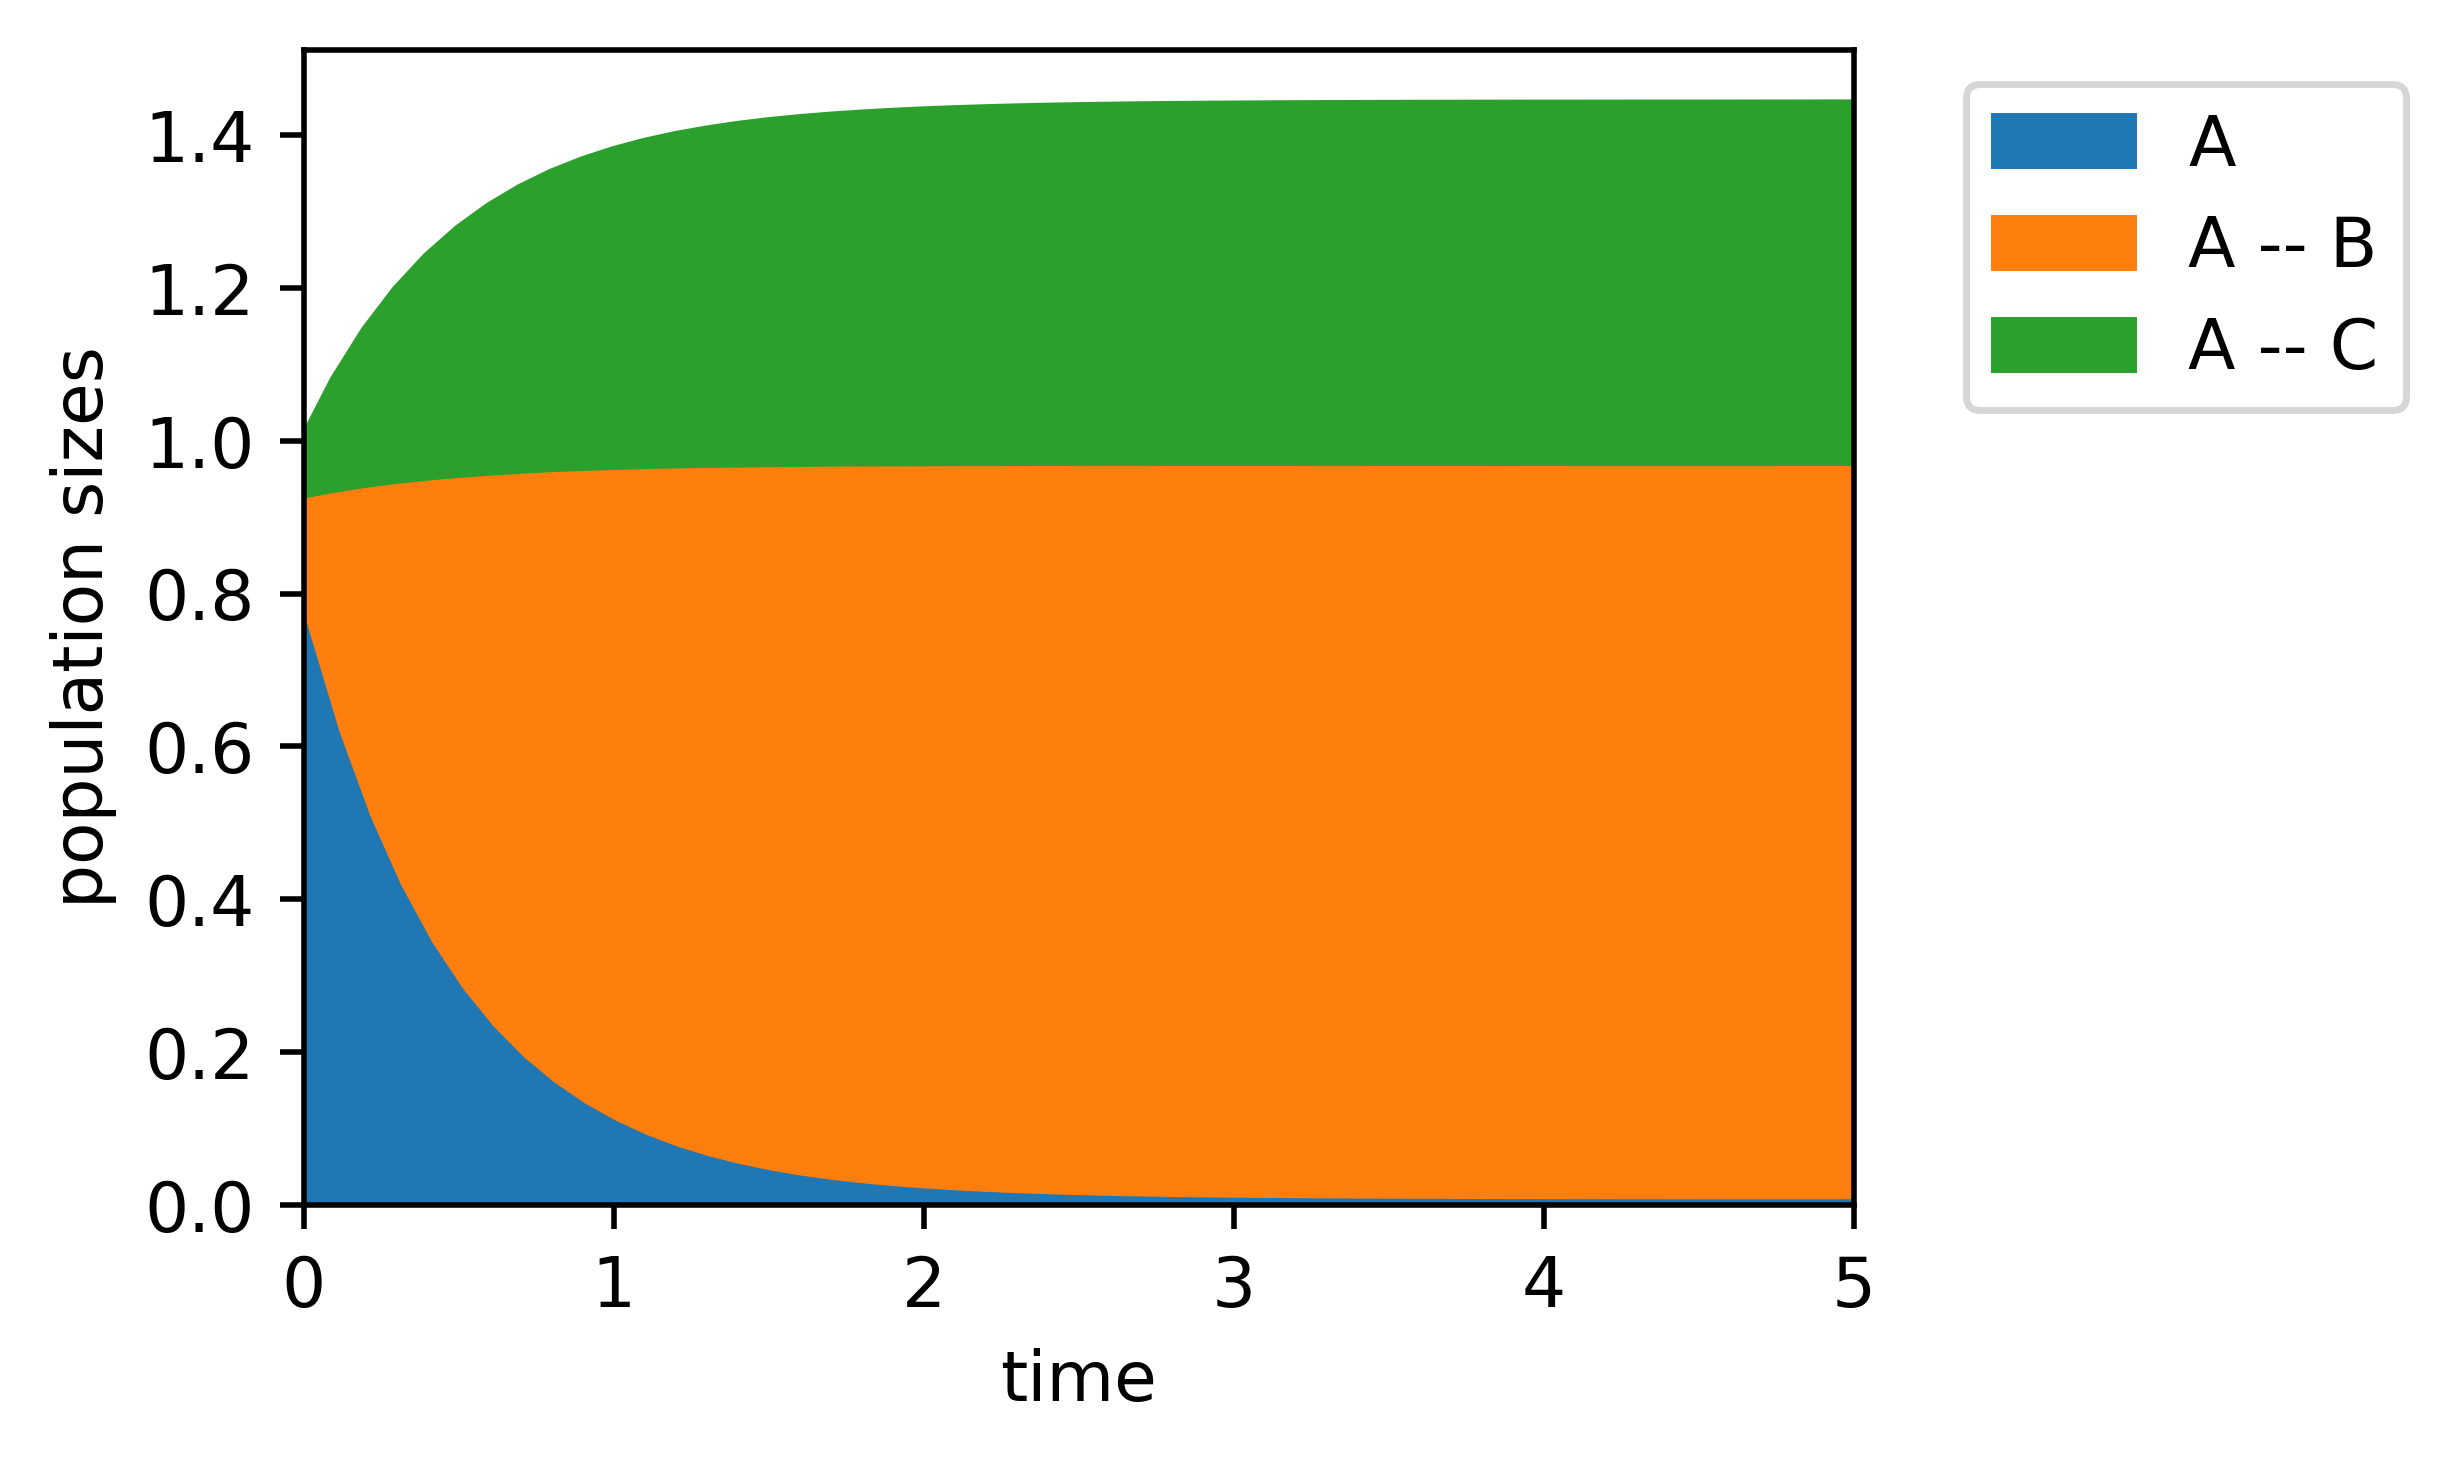

In [141]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
clean_states.multiply(popratio, axis=0).plot.area(ax=ax)
plt.xlim(0,5)
# plt.ylim(0,2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("time")
plt.ylabel("population sizes")

### PopMaBoSS

In [143]:
sim = maboss.PopSimulation("tuto/popmaboss/Fork-uneven.bnd", "tuto/popmaboss/Fork-uneven.cfg")

In [144]:
res = sim.run()

Text(0, 0.5, 'probabilities')

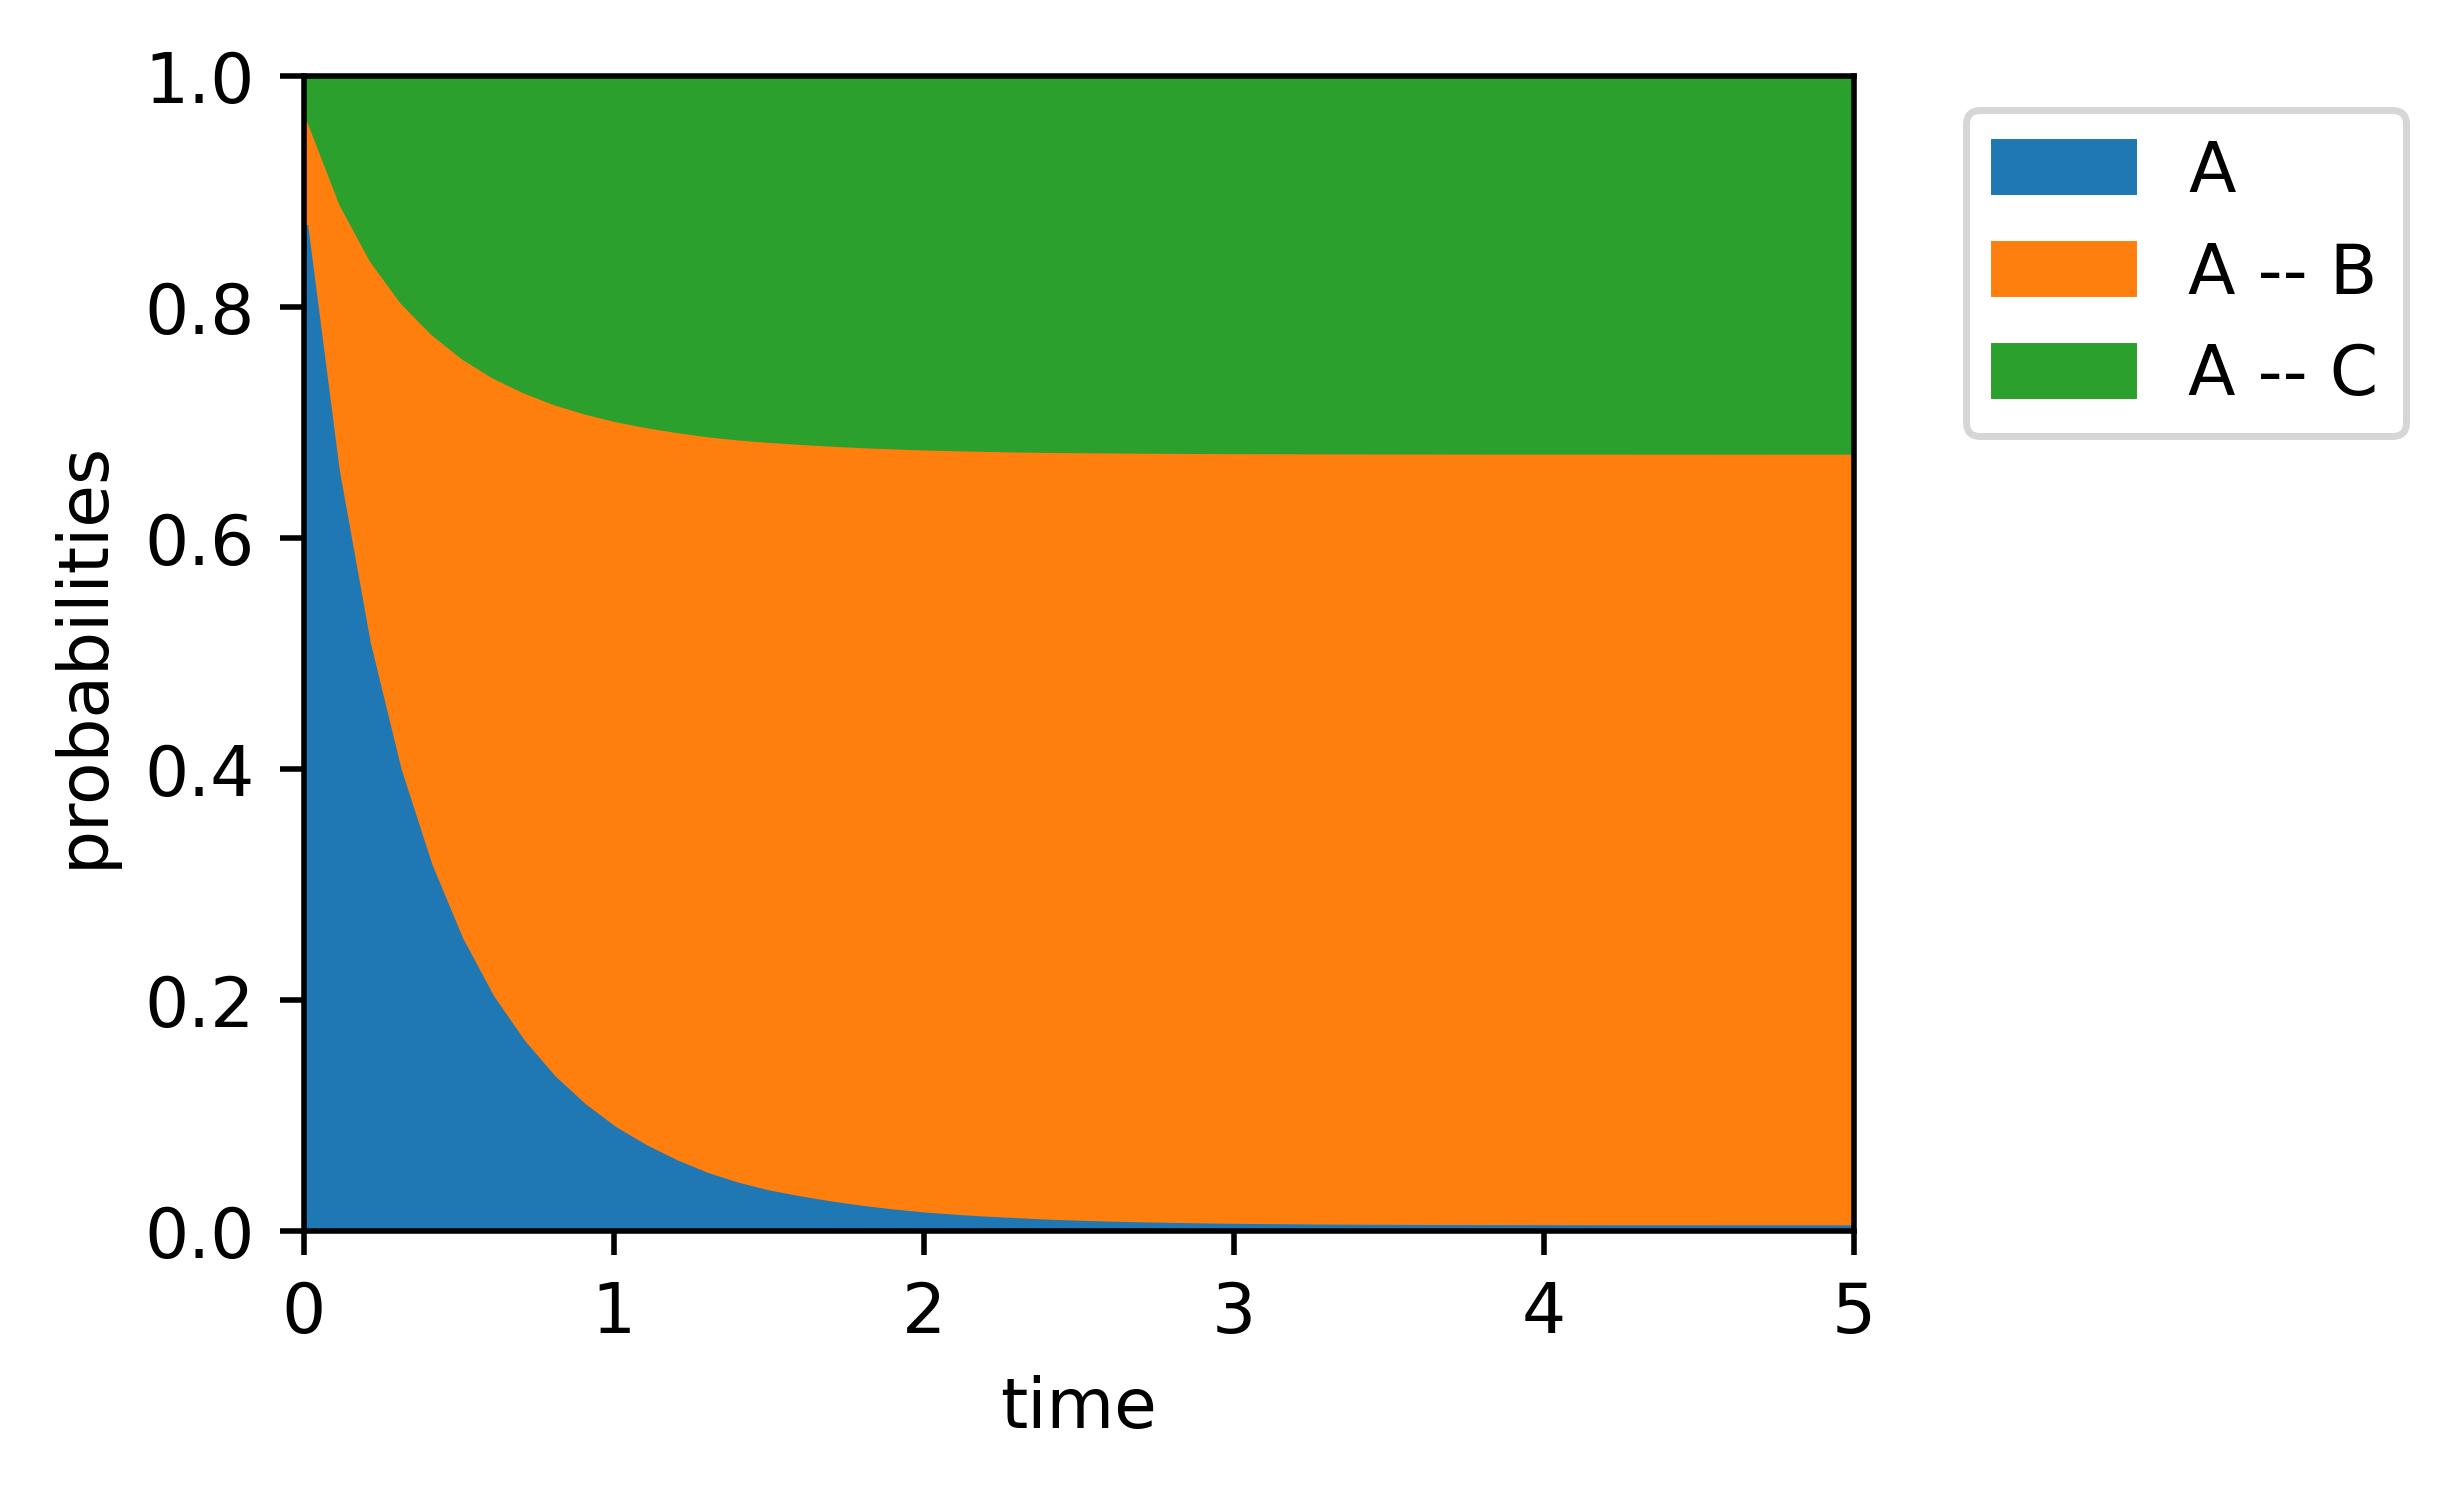

In [145]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
res.get_simple_states_probtraj().plot.area(ax=ax)
plt.xlim(0,5)
plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("time")
plt.ylabel("probabilities")


Text(0, 0.5, 'population size')

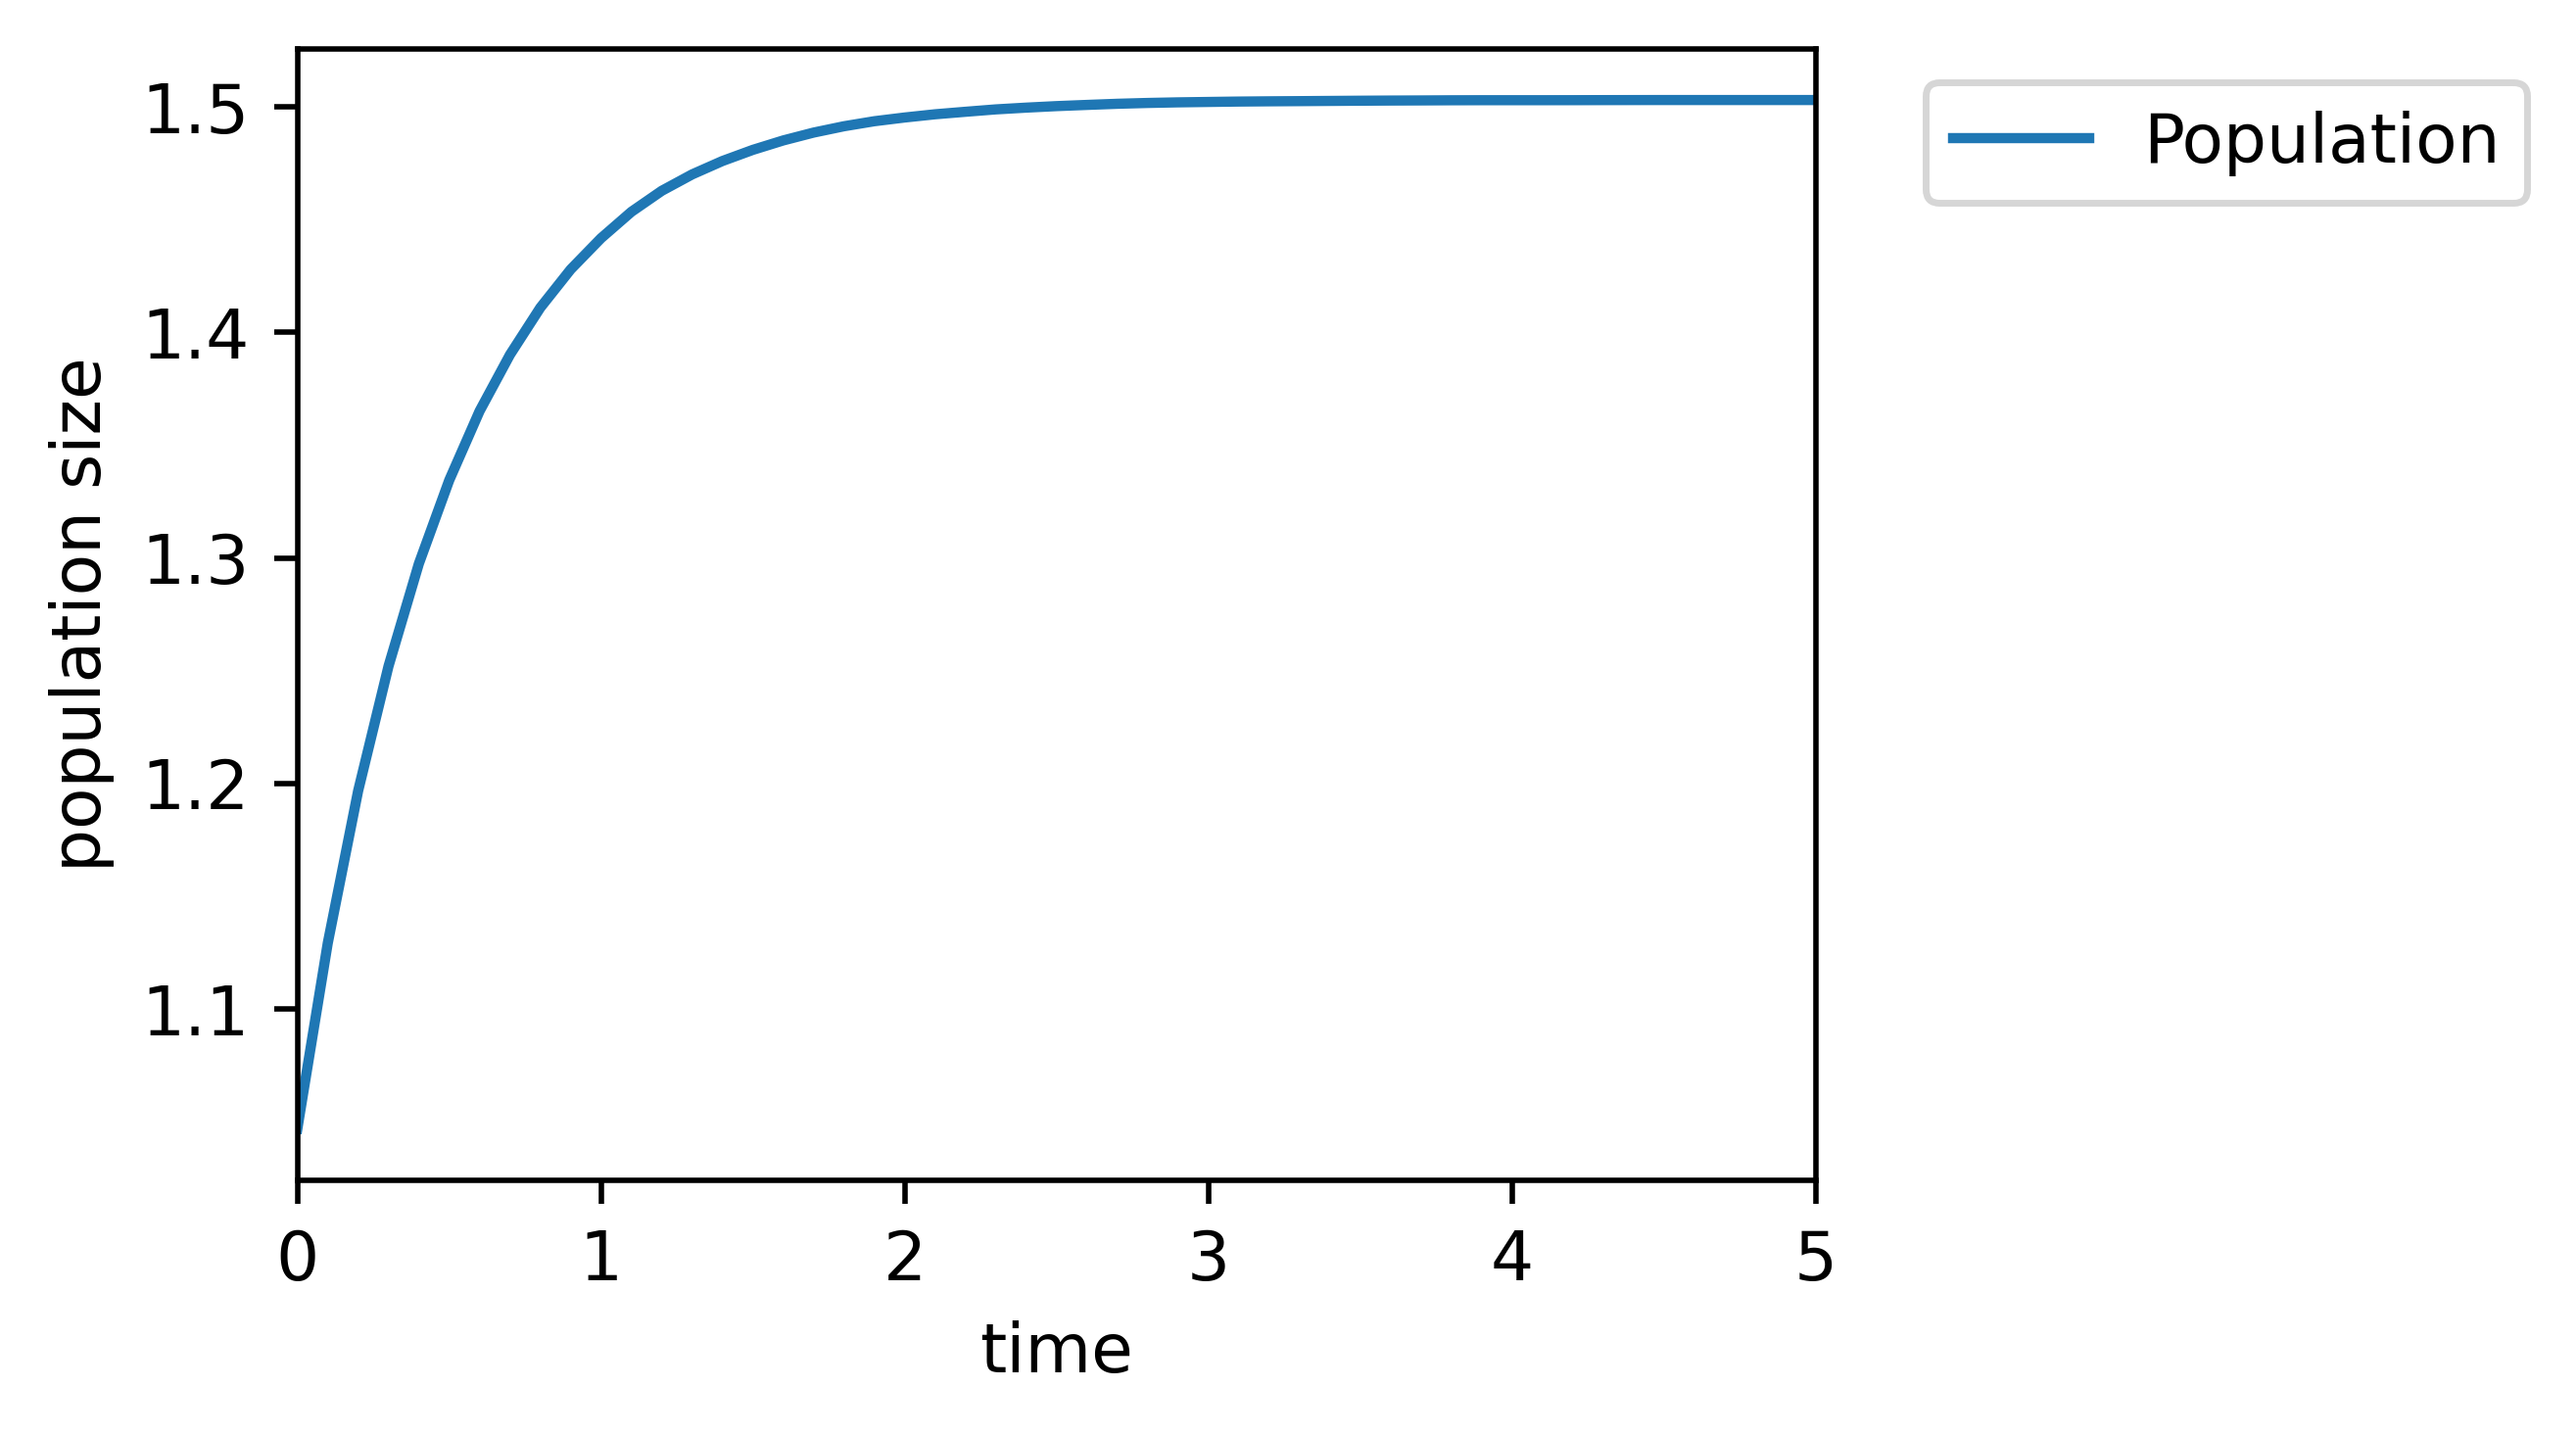

In [147]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
res.get_simple_popsize().plot(ax=ax)
plt.xlim(0,5)
# plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("time")
plt.ylabel("population size")

Text(0, 0.5, 'population sizes')

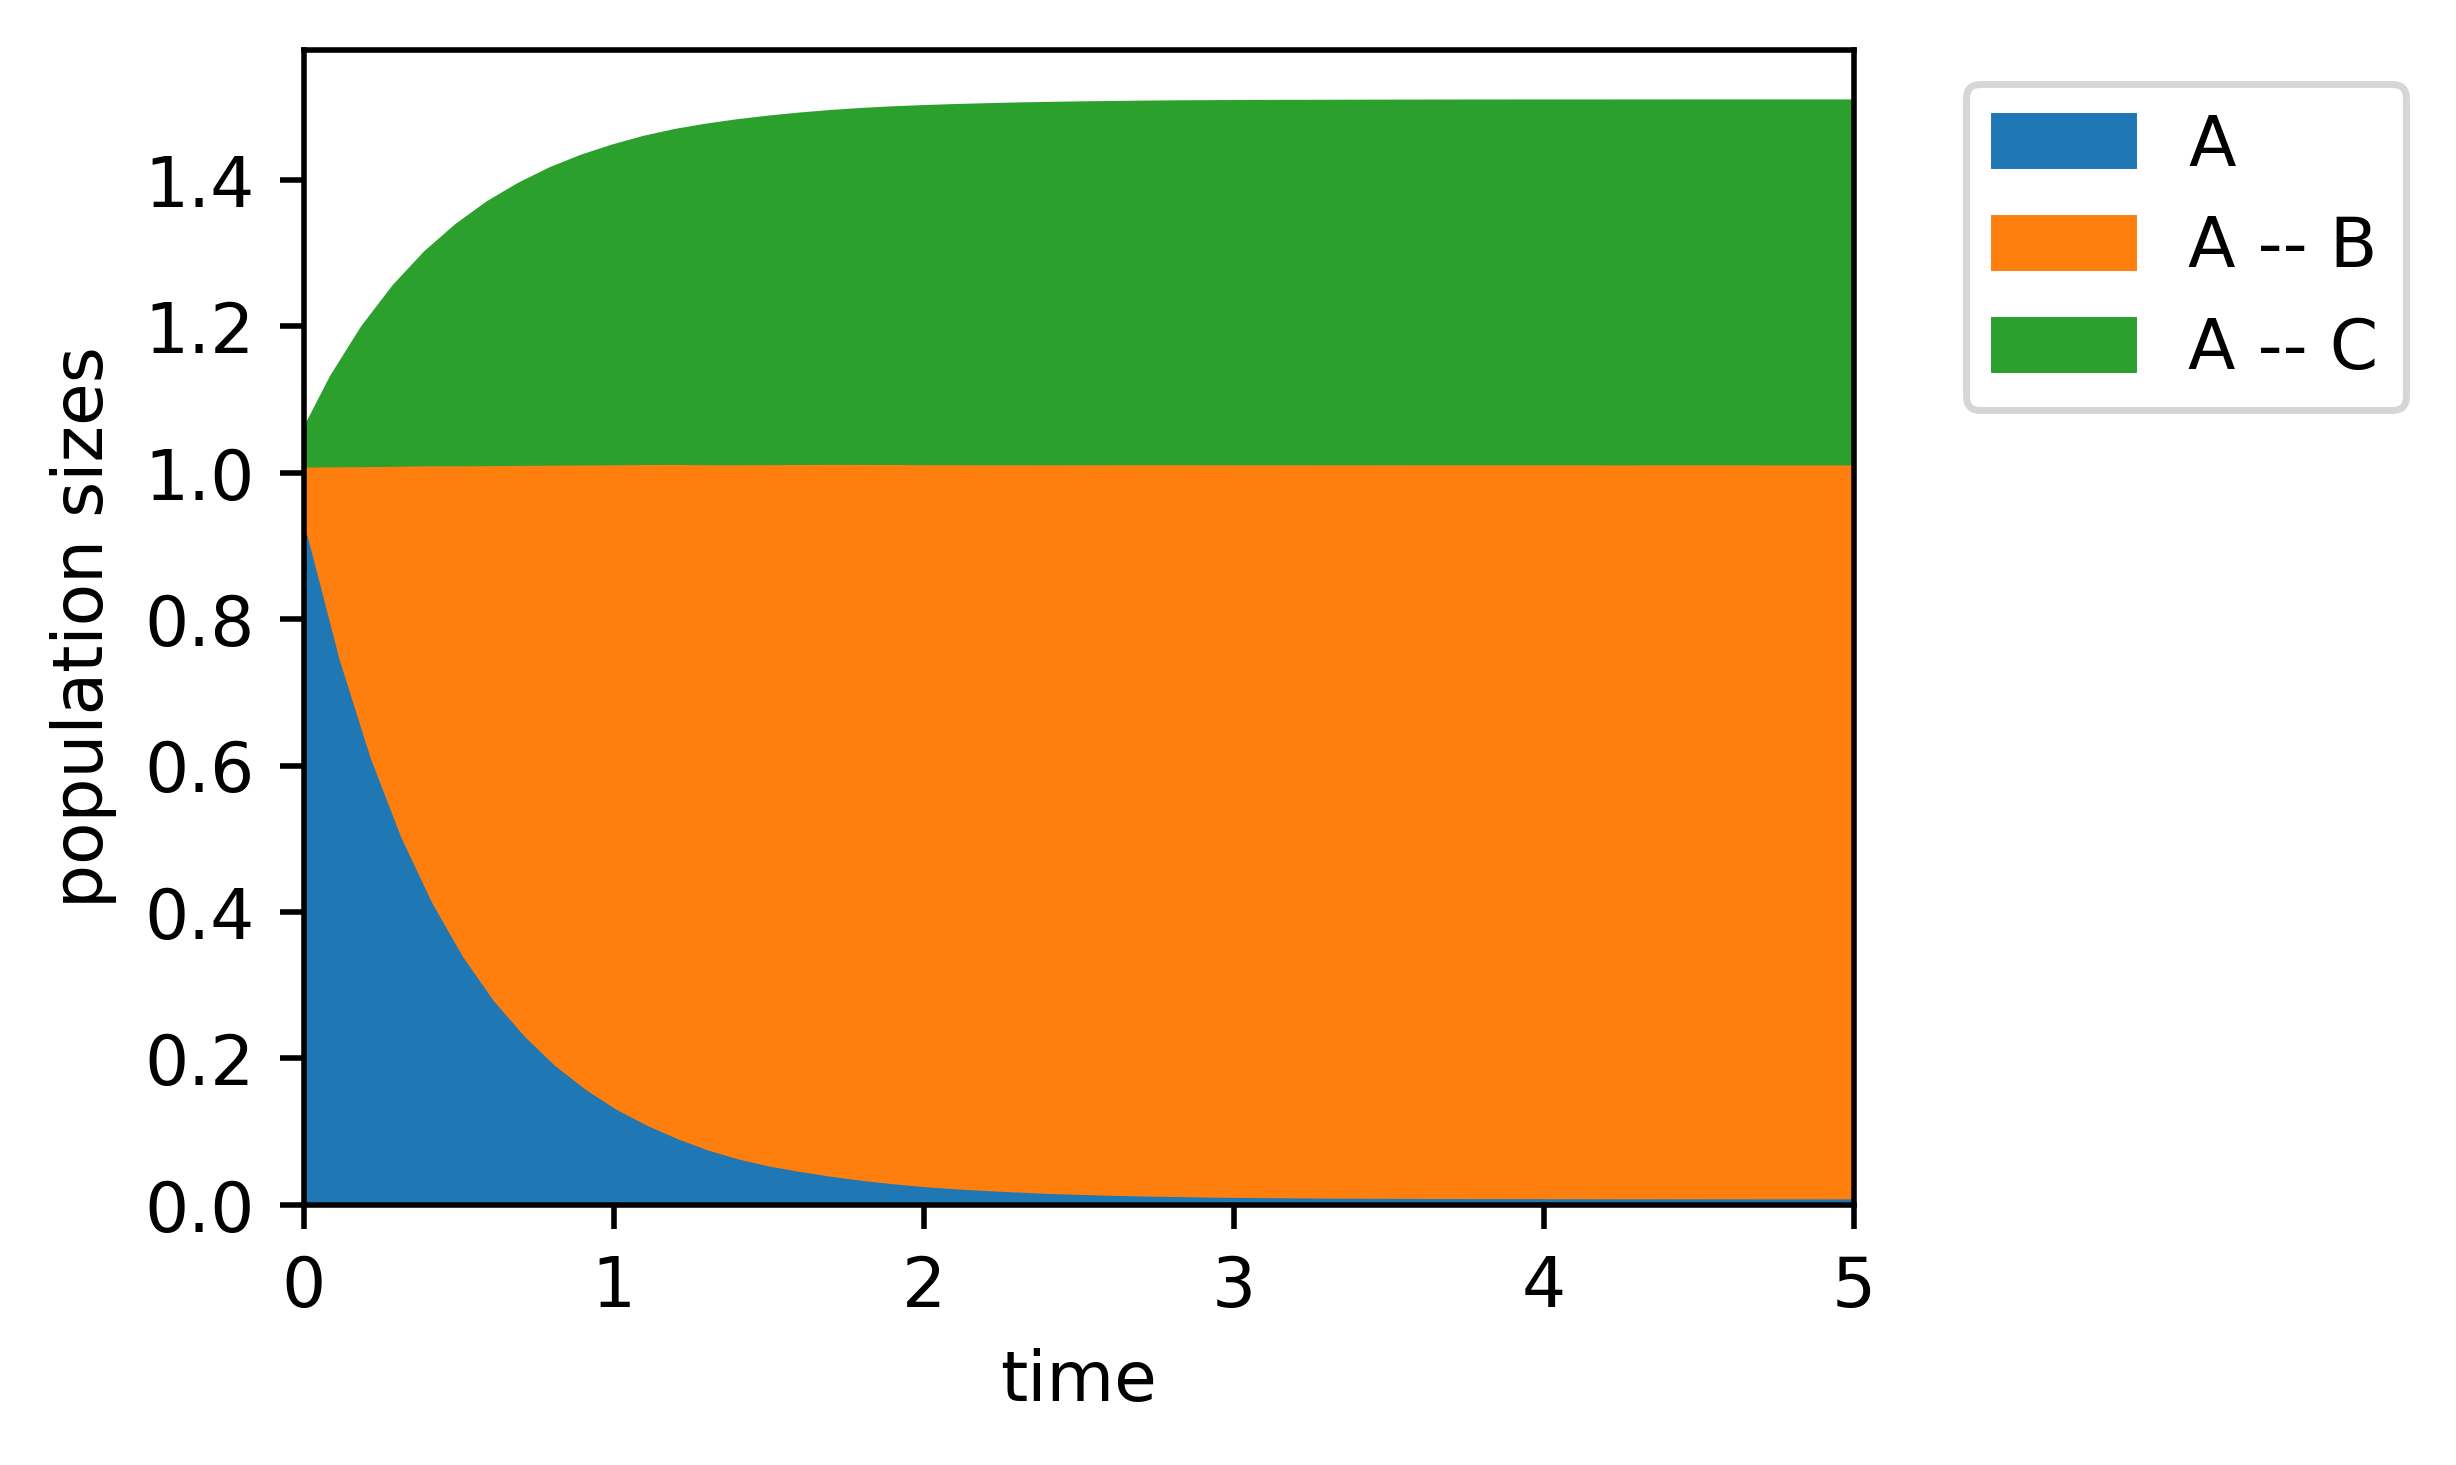

In [148]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
res.get_simple_states_popsize().plot.area(ax=ax)
plt.xlim(0,5)
# plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("time")
plt.ylabel("population sizes")

(-0.5, 8.0)

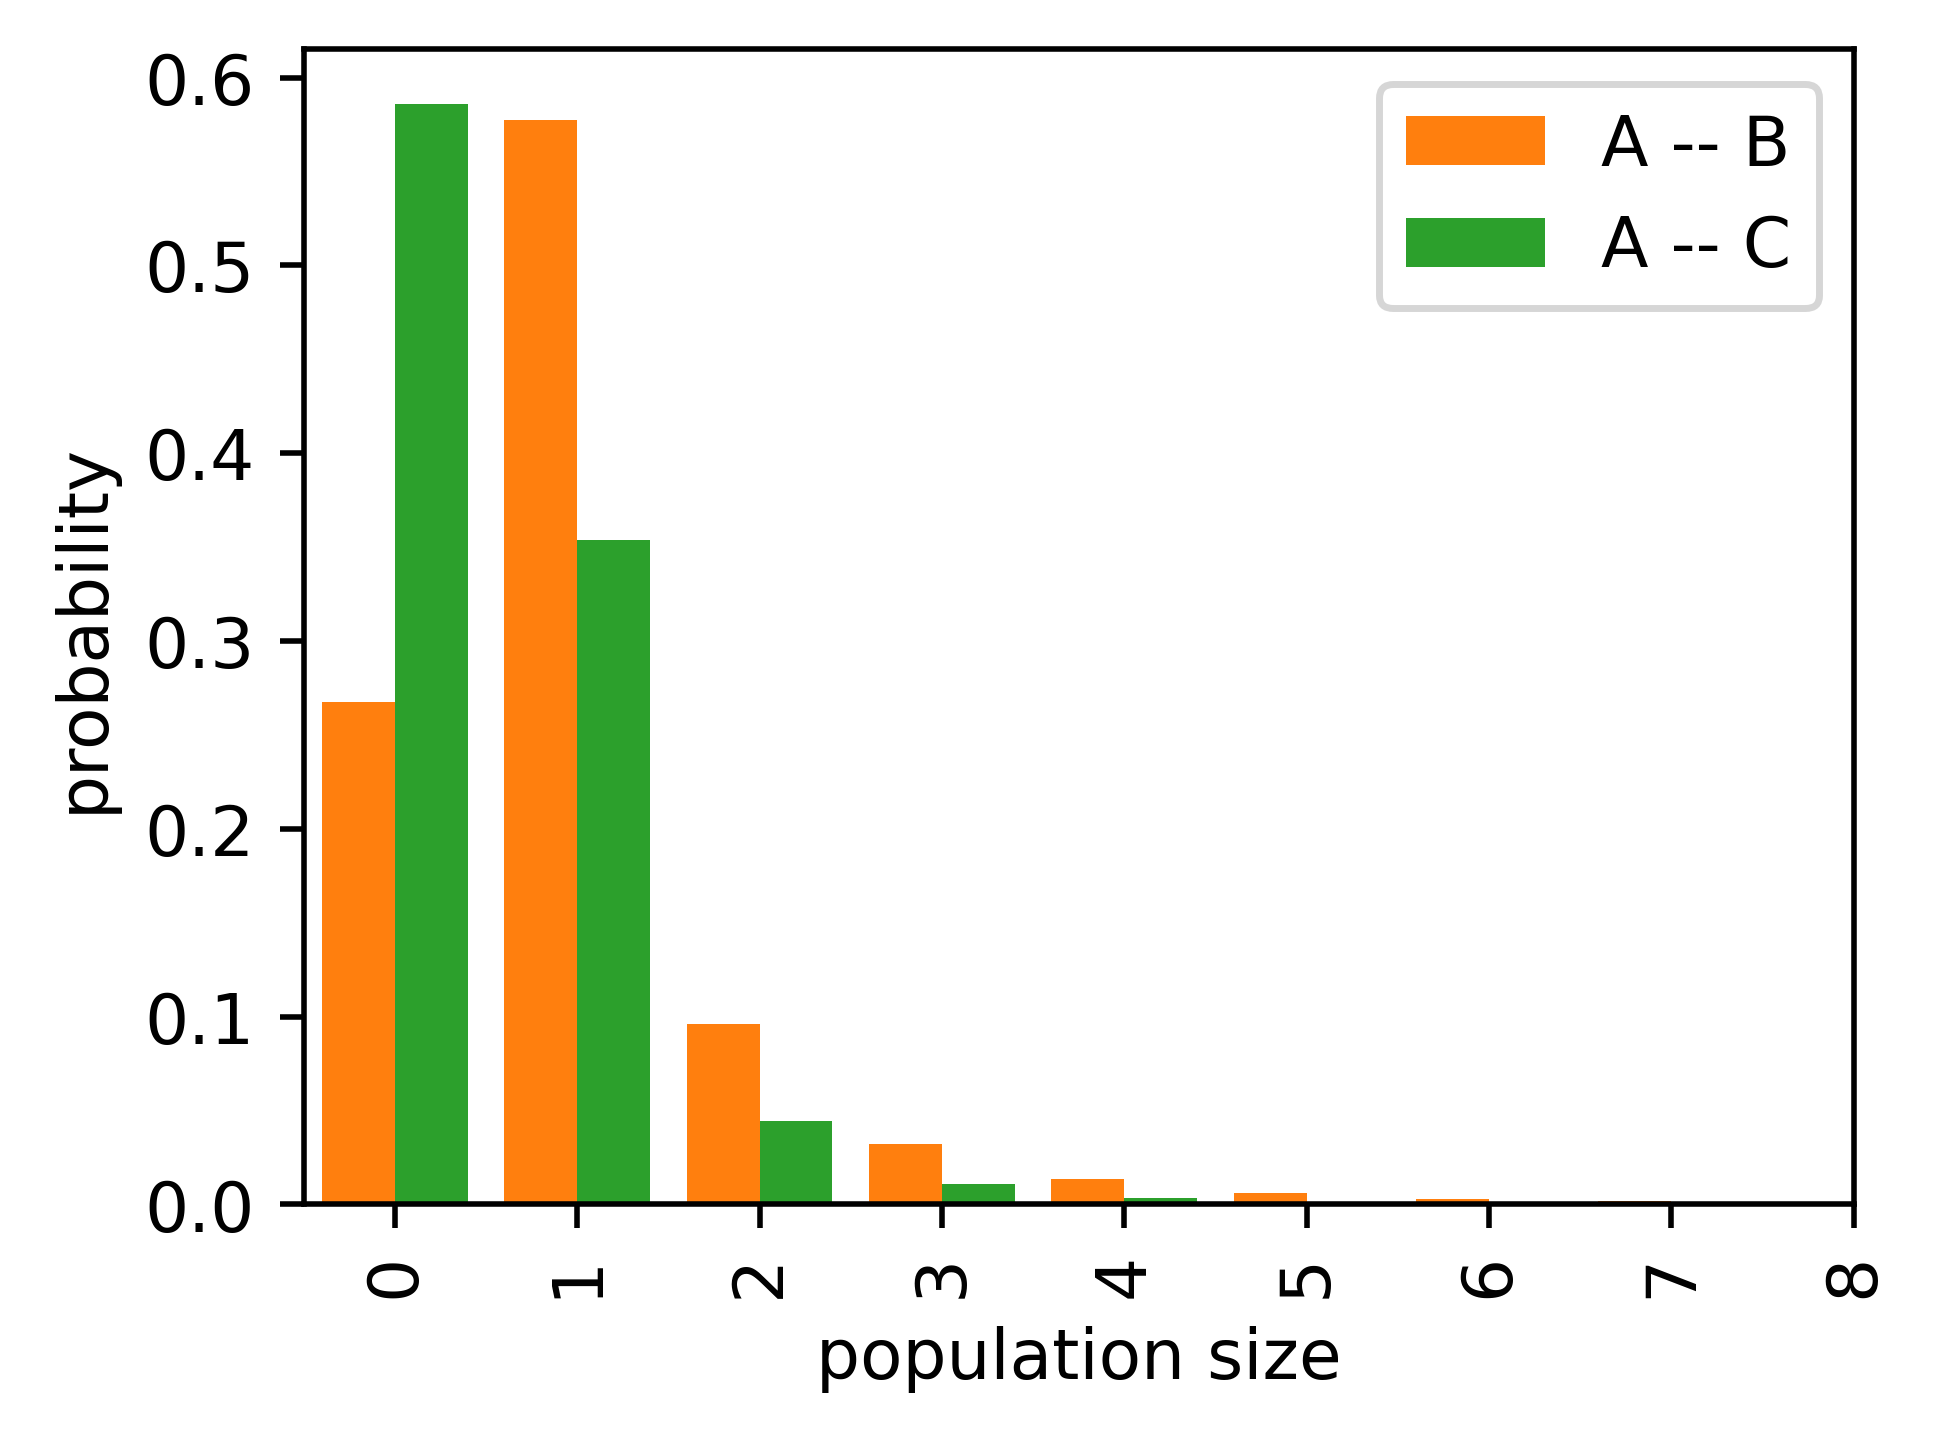

In [154]:
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=500)
simple = res.get_last_state_dist('A -- B', rescale=False)
simple[0] = 1.0 - simple.sum()
simple.sort_index(inplace=True)
simple2 = res.get_last_state_dist('A -- C', rescale=False)
simple2[0] = 1.0 - simple2.sum()
simple2.sort_index(inplace=True)
simples = pd.DataFrame([simple, simple2], index=["A -- B", "A -- C"]).transpose()
simples.fillna(0.0)
simples.plot.bar(ax=ax, width=0.8, color={'A -- B': 'C1', 'A -- C' : 'C2'})

plt.ylabel("probability")
plt.xlabel("population size")
plt.xlim(-0.5,8)